# Python Revision Notebook
### Open Book Exam Reference — All Topics in One File

---

## 📚 Table of Contents
0. [Imports](#0-imports)
1. [Lists & Sorting](#1-lists--sorting)
2. [Sets](#2-sets)
3. [While Loops & Break](#3-while-loops--break)
4. [String Formatting](#4-string-formatting)
5. [File I/O](#5-file-io)
6. [Web Requests & Error Handling](#6-web-requests--error-handling)
7. [CSV Files](#7-csv-files)
8. [JSON & XML Parsing](#8-json--xml-parsing)
9. [Web Scraping (BeautifulSoup)](#9-web-scraping-beautifulsoup)
10. [APIs](#10-apis)
11. [Pandas — DataFrames](#11-pandas--dataframes)
12. [Matplotlib — Plotting](#12-matplotlib--plotting)
13. [Machine Learning — Linear Regression](#13-machine-learning--linear-regression)
14. [Machine Learning — Classification & Evaluation](#14-machine-learning--classification--evaluation)
15. [Text Processing & NLP](#15-text-processing--nlp)
16. [Feature Selection & Importance](#16-feature-selection--importance)

---
## 0. Imports

In [53]:
# Imports
# Standard library
import re
import json
import csv
import random
import calendar
import urllib.request
import urllib.error
import xml.etree.ElementTree

# Data & IO
import numpy as np
import pandas as pd
from io import StringIO

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# Web scraping
import bs4
from bs4 import BeautifulSoup

# sklearn — preprocessing & model selection
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# sklearn — models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn import linear_model

# sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# sklearn — feature selection & importance
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

---
## 1. Lists & Sorting

Key methods:
- `list.sort(key=...)` — sort in place by a key function
- `list.sort(reverse=True)` — sort in descending order
- `list.reverse()` — reverse the list in place

In [1]:
# Sort words by length (shortest first)
words = ["elephant", "cat", "butterfly", "dog", "ant"]
words.sort(key=len)
print("Words by length:", words)

Words by length: ['cat', 'dog', 'ant', 'elephant', 'butterfly']


In [2]:
# Sort numbers in descending order
numbers2 = [45, 12, 87, 3, 99, 21]
numbers2.sort(reverse=True)
print("Descending:", numbers2)

Descending: [99, 87, 45, 21, 12, 3]


In [3]:
# Reverse the order of a list (does NOT sort, just reverses)
colors = ["red", "green", "blue", "yellow"]
print("Original:", colors)
colors.reverse()
print("Reversed:", colors)

Original: ['red', 'green', 'blue', 'yellow']
Reversed: ['yellow', 'blue', 'green', 'red']


In [4]:
# Remove a specific value from a list
mylist = [1, 3, 5, 8, 10]
mylist.remove(8)  # removes the first occurrence of 8
print("After remove(8):", mylist)

After remove(8): [1, 3, 5, 10]


---
## 2. Sets

Key methods:
- `set.add(value)` — add a single value
- `set.update([...])` — add multiple values
- `set.difference(other)` — values in set but not in other

In [5]:
names = {"Alice", "Bob"}

# Add a single value
names.add("Catherine")
print(names)

# Add multiple values
names.update(["Bob", "Alice", "John"])  # duplicates are ignored
print(names)

# Find values in names but not in another set
enrolled = {"Alice", "John"}
not_enrolled = names.difference(enrolled)
print("Not enrolled:", not_enrolled)

{'Catherine', 'Alice', 'Bob'}
{'John', 'Catherine', 'Alice', 'Bob'}
Not enrolled: {'Bob', 'Catherine'}


---
## 3. While Loops & Break

- `while condition:` — keep looping while condition is True
- `break` — exit the loop immediately when a condition is met
- `counter % 3 == 0` — check divisibility using modulo

In [6]:
# Loop while counter < 8, break if divisible by 3
counter = 1
while counter < 8:
    print(f"counter is currently {counter}")
    if counter % 3 == 0:
        print(f"breaking out of loop when counter is {counter}")
        break
    counter += 1

counter is currently 1
counter is currently 2
counter is currently 3
breaking out of loop when counter is 3


---
## 4. String Formatting

f-string format spec cheatsheet:
- `{name:*^15}` — center in 15 chars, padded with `*`
- `{value:>8.1f}` — right-align in 8 chars, 1 decimal place
- `{n:,.2f}` — thousands separator, 2 decimal places
- `{n:.2e}` — scientific notation
- `{n:.1%}` — percentage
- `abs(-15)` — absolute value

In [ ]:
name = "Alice"

# Center name in 15 characters, padded with *
print(f"Custom padding: {name:*^15}")

# Number formatting
large_number = 1234567.89
print(f"With commas:  {large_number:,.2f}")
print(f"Scientific:   {large_number:.2e}")
print(f"Percentage:   {0.156:.1%}")

# Right-align in 8 chars with 1 decimal
avg = 93.45
print(f"Right-align: {avg:>8.1f}")

# Absolute value
print(f"abs(-15) = {abs(-15)}")

# str.find() — returns -1 if not found
s = "hello world"
print(f's.find("bye") = {s.find("bye")}')  # -1 means not found, gives starting index when found

Custom padding: *****Alice*****
With commas:  1,234,567.89
Scientific:   1.23e+06
Percentage:   15.6%
Right-align:     93.5
abs(-15) = 15
s.find("bye") = -1


---
## 5. File I/O

- Use `with open(...)` — automatically closes the file
- `readlines()` — returns list of lines (includes `\n`)
- `read().splitlines()` — returns list of lines without `\n`
- `l.strip()` — removes leading/trailing whitespace

In [57]:
# Write a sample file first
with open("data.txt", "w") as f:
    f.write("line one\nline two\nline three\n")

# Read using readlines() + strip()
with open("data.txt", "r") as fin:
    lines = fin.readlines()
    for l in lines:
        print(l.strip())

print("---")

# Read using splitlines() — cleaner, no trailing \n
with open("data.txt", "r") as fin:
    lines = fin.read().splitlines()
    print("Read %d lines of text" % len(lines))
    print(lines)

# with error handling
try:
   with open("data.txt", "r") as fin:
       lines = fin.readlines()
  
except IOError as e:
   print(f"File Error: Could not read goal_data.csv - {e}")

except Exception as e:
   print(f"Unexpected error: {e}")


# downloading a File
# specify a URL that does not exist
url = "http://mlg.ucd.ie/modules/python/goal_scorers.csv"


try:
   # attempt to retrieve the URL
   response = urllib.request.urlopen(url)
   text = response.read().decode("utf-8")
   print("Done")
except urllib.error.HTTPError as e:
   print(f"HTTP Error {e.code}: Failed to retrieve {url}")
except urllib.error.URLError as e:
   print(f"Network Error: Failed to retrieve {url} - {e.reason}")
except Exception as e:
   print(f"Unexpected error retrieving {url}: {e}")

line one
line two
line three
---
Read 3 lines of text
['line one', 'line two', 'line three']
Done


---
## 6. Web Requests & Error Handling

Use `urllib.request` to fetch URLs. Always wrap in `try/except`:
- `urllib.error.HTTPError` — bad status code (404, 500, etc.)
- `urllib.error.URLError` — network/DNS failure
- `Exception` — catch-all fallback

In [9]:
import urllib.request
import urllib.error

# Example: request a URL that does not exist
url = "http://somemissinglink.ucd.ie/ucd.txt"
try:
    response = urllib.request.urlopen(url)
    text = response.read().decode("utf-8")
    print(text)
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: Failed to retrieve {url}")
except urllib.error.URLError as e:
    print(f"Network Error: Failed to retrieve {url} - {e.reason}")
except Exception as e:
    print(f"Unexpected error retrieving {url}: {e}")

Network Error: Failed to retrieve http://somemissinglink.ucd.ie/ucd.txt - [Errno 8] nodename nor servname provided, or not known


In [10]:
# Fetch a URL and add a browser-like User-Agent header (required by some sites)
url = "https://en.wikipedia.org/w/api.php"
keyword = "Dublin"
full_url = "%s?action=query&list=search&format=json&srsearch=%s" % (url, keyword)

try:
    headers = {"User-Agent": "Mozilla/5.0"}
    req = urllib.request.Request(full_url, headers=headers)
    response = urllib.request.urlopen(req)
    if response.getcode() == 200:
        raw_json = response.read().decode("utf-8")
        print(f"Successfully retrieved data (HTTP {response.getcode()})")
        print(raw_json[:300])  # preview first 300 chars
    else:
        print(f"Unexpected HTTP status code: {response.getcode()}")
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: {e.reason}")
except urllib.error.URLError as e:
    print(f"Network Error: {e.reason}")
except Exception as e:
    print(f"Unexpected error: {e}")

Successfully retrieved data (HTTP 200)
{"batchcomplete":"","continue":{"sroffset":10,"continue":"-||"},"query":{"searchinfo":{"totalhits":86876},"search":[{"ns":0,"title":"Dublin","pageid":8504,"size":183197,"wordcount":16538,"snippet":"<span class=\"searchmatch\">Dublin</span> is the capital and largest city of Ireland. Situated on <spa


---
## 7. CSV Files

- Download CSV from URL → decode → split lines → parse
- Use `csv.DictReader` to read rows as dicts
- Use `csv.DictWriter` to write rows from dicts
- Use `pandas.read_csv(StringIO(raw_csv))` to load directly into DataFrame

In [11]:
import urllib.request
import urllib.error

# Download CSV and parse line by line
url = "http://mlg.ucd.ie/modules/python/goal_scorers.csv"
try:
    response = urllib.request.urlopen(url)
    raw_csv = response.read().decode("utf-8")
    lines = raw_csv.split("\n")
    for line in lines:
        line = line.strip()
        if len(line) > 0:
            parts = line.split(",")
            print(parts)
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: Could not download CSV file")
except urllib.error.URLError as e:
    print(f"Network Error: {e.reason}")
except Exception as e:
    print(f"Unexpected error: {e}")

['Player', 'Club', 'Total Goals', 'Home Goals', 'Away Goals']
['Jamie Vardy', 'Leicester City', '17', '8', '9']
['Sergio Aguero', 'Manchester City', '16', '8', '8']
['P. Aubameyang', 'Arsenal', '15', '6', '9']
['Danny Ings', 'Southampton', '15', '8', '7']
['Marcus Rashford', 'Manchester Utd', '14', '10', '4']
['Mohamed Salah', 'Liverpool', '14', '12', '2']
['Tammy Abraham', 'Chelsea', '13', '5', '8']
['Sadio Mané', 'Liverpool', '12', '7', '5']
['Raúl Jiménez', 'Wolverhampton', '11', '5', '6']
['Harry Kane', 'Tottenham', '11', '6', '5']
['D. Calvert-Lewin', 'Everton', '11', '6', '5']
['Raheem Sterling', 'Manchester City', '11', '2', '9']
['Teemu Pukki', 'Norwich City', '11', '7', '4']
['Chris Wood', 'Burnley', '10', '6', '4']
['Son Heungmin', 'Tottenham', '9', '6', '3']
['Anthony Martial', 'Manchester Utd', '9', '4', '5']
['Richarlison', 'Everton', '9', '5', '4']
['Kevin De Bruyne', 'Manchester City', '9', '6', '3']
['Gabriel Jesus', 'Manchester City', '9', '3', '6']
['Roberto Firmino',

In [ ]:
import pandas as pd
from io import StringIO

# Load CSV directly into a pandas DataFrame
url = "http://mlg.ucd.ie/modules/python/goal_scorers.csv"
try:
    response = urllib.request.urlopen(url)
    raw_csv = response.read().decode("utf-8")
    df = pd.read_csv(StringIO(raw_csv)) # makes it a dummy file 
    print(df.head())
except Exception as e:
    print(f"Error: {e}")

            Player             Club  Total Goals  Home Goals  Away Goals
0      Jamie Vardy   Leicester City           17           8           9
1    Sergio Aguero  Manchester City           16           8           8
2    P. Aubameyang          Arsenal           15           6           9
3       Danny Ings      Southampton           15           8           7
4  Marcus Rashford   Manchester Utd           14          10           4


In [13]:
import csv

# Download and save to file, then read with csv.DictReader
url = "http://mlg.ucd.ie/modules/python/goal_scorers.csv"
try:
    response = urllib.request.urlopen(url)
    data = response.read().decode("utf-8")
    with open("goal_data.csv", "w", encoding="utf-8") as fout:
        fout.write(data)
    print("Successfully downloaded and saved goal_data.csv")
except Exception as e:
    print(f"Error: {e}")

# Read back using csv.DictReader
rows = []
try:
    with open("goal_data.csv", "r", encoding="utf-8") as fin:
        reader = csv.DictReader(fin)
        for row_num, row in enumerate(reader, 1):
            try:
                rows.append(row)
            except Exception as e:
                print(f"Error processing row {row_num}: {e}")
    print(f"Successfully read {len(rows)} rows of data")
    print(rows[0])  # preview first row
except Exception as e:
    print(f"Error: {e}")

Successfully downloaded and saved goal_data.csv
Successfully read 30 rows of data
{'Player': 'Jamie Vardy', 'Club': 'Leicester City', 'Total Goals': '17', 'Home Goals': '8', 'Away Goals': '9'}


In [14]:
# Write rows to a new CSV using csv.DictWriter
try:
    with open("output.csv", "w", encoding="utf-8", newline="") as fout:
        fields = ["Player", "Club", "Total Goals", "Home Goals", "Away Goals"]
        writer = csv.DictWriter(fout, fieldnames=fields)
        writer.writeheader()       # write column headers
        for row in rows:
            writer.writerow(row)
    print(f"Successfully wrote {len(rows)} rows to output.csv")
except Exception as e:
    print(f"Error: {e}")

Successfully wrote 30 rows to output.csv


---
## 8. JSON & XML Parsing

- `json.loads(string)` / `json.dumps(obj)` — convert between JSON string and Python object (`s` = string)
- `xml.etree.ElementTree.fromstring(raw_xml)` — parse XML
- `tree.findall("book")` — find all matching tags
- `book.find("title").text` — get text inside a tag
- `child.tag`, `child.attrib` — tag name and attributes (e.g. `id` number)

In [15]:
import json

# Download and parse JSON
url = "http://mlg.ucd.ie/modules/python/books.json"
raw_json = None
try:
    response = urllib.request.urlopen(url)
    raw_json = response.read().decode("utf-8")
    print("Successfully downloaded JSON data")
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: Could not download JSON file")
except Exception as e:
    print(f"Unexpected error: {e}")

try:
    data = json.loads(raw_json)   # loads = load from string
    print("Successfully parsed JSON data")
    for book in data:
        print(book)
except json.JSONDecodeError as e:
    print(f"JSON Error: Invalid JSON format - {e}")
except Exception as e:
    print(f"Unexpected error parsing JSON: {e}")

Successfully downloaded JSON data
Successfully parsed JSON data
{'book_id': '13585350', 'title': 'The World Treasury of Science Fiction', 'ISBN': '0316349410', 'year': 1989, 'rating': 3, 'language': 'eng'}
{'book_id': '124205572', 'title': 'The War of the Worlds', 'ISBN': '1936594056', 'year': 2013, 'rating': 4, 'language': 'eng'}
{'book_id': '127360065', 'title': 'Under the Dome: A Novel', 'ISBN': '1439149038', 'year': 2013, 'rating': 2, 'language': 'eng'}
{'book_id': '13908800', 'title': "The Ultimate Hitchhiker's Guide to the Galaxy", 'ISBN': '0345453743', 'year': 2002, 'rating': 5, 'language': 'eng'}
{'book_id': '123734934', 'title': "The Time Traveler's Wife", 'ISBN': '1476764832', 'year': 2014, 'rating': 5, 'language': 'eng'}
{'book_id': '13603020', 'title': "Salem's Lot", 'ISBN': '0451098277', 'year': 1976, 'rating': 3, 'language': 'eng'}
{'book_id': '124173974', 'title': 'Republic', 'ISBN': '039395501X', 'year': 1985, 'rating': 3, 'language': 'eng'}
{'book_id': '123102859', 'ti

In [16]:
import xml.etree.ElementTree

# Download and parse XML
url = "http://mlg.ucd.ie/modules/python/books.xml"
raw_xml = None
try:
    response = urllib.request.urlopen(url)
    raw_xml = response.read().decode("utf-8")
    print("Successfully downloaded XML data")
except Exception as e:
    print(f"Unexpected error: {e}")
    raw_xml = None

tree = None
try:
    tree = xml.etree.ElementTree.fromstring(raw_xml)
    print("Successfully parsed XML data")
except Exception as e:
    print(f"Error parsing XML: {e}")

# Print immediate children — shows tag name and attributes (e.g. id=...)
if tree is not None:
    for child in tree:
        print(child.tag, child.attrib)

Successfully downloaded XML data
Successfully parsed XML data
book {'id': '13585350'}
book {'id': '124205572'}
book {'id': '127360065'}
book {'id': '13908800'}
book {'id': '123734934'}
book {'id': '13603020'}
book {'id': '124173974'}
book {'id': '123102859'}


In [17]:
# Extract and sort all book titles from XML
titles = []
if tree is not None:
    for book in tree.findall("book"):
        title_element = book.find("title")
        if title_element is not None and title_element.text:
            title = title_element.text.strip()
            titles.append(title)
        else:
            print("Warning: Book found without a title")

    for title in sorted(titles):
        print(f"- {title}")

# Example XML structure for reference:
# <booklist>
#   <book id="13585350">
#     <title>The World Treasury of Science Fiction</title>
#     <ISBN>0316349410</ISBN>
#     <year>1989</year>
#     <rating>3</rating>
#     <language>eng</language>
#   </book>
# </booklist>

- Republic
- Salem's Lot
- The Road
- The Time Traveler's Wife
- The Ultimate Hitchhiker's Guide to the Galaxy
- The War of the Worlds
- The World Treasury of Science Fiction
- Under the Dome: A Novel


---
## 9. Web Scraping (BeautifulSoup)

- `bs4.BeautifulSoup(html, 'html.parser')` — parse HTML
- `soup.find_all("div", {"class": "person"})` — find all matching tags
- `match.find("span", {"class": "firstname"})` — find within a match
- `.get_text()` — extract plain text from HTML (useful for cleaning)

In [18]:
import bs4

# Assume html was fetched from a URL (see section 6)
sample_html = """
<html><body>
  <div class="person">
    <span class="firstname">John</span>
    <span class="lastname">Doe</span>
    <span class="dob">1990-01-15</span>
  </div>
  <div class="person">
    <span class="firstname">Jane</span>
    <span class="lastname">Smith</span>
    <span class="dob">1985-07-22</span>
  </div>
</body></html>
"""

soup = bs4.BeautifulSoup(sample_html, 'html.parser')

# Find all <div class="person"> tags
person_matches = soup.find_all("div", {"class": "person"})

if person_matches:
    print(f"Found {len(person_matches)} person records:")
    for i, match in enumerate(person_matches, 1):
        firstname_elem = match.find("span", {"class": "firstname"})
        lastname_elem  = match.find("span", {"class": "lastname"})
        dob_elem       = match.find("span", {"class": "dob"})
        print(f"{i}. {firstname_elem.text} {lastname_elem.text} — DOB: {dob_elem.text}")
else:
    print("No person records found with class 'person'")

Found 2 person records:
1. John Doe — DOB: 1990-01-15
2. Jane Smith — DOB: 1985-07-22


In [19]:
# html_to_text — strip HTML tags and return plain text
def html_to_text(html):
    if not isinstance(html, str):
        return ""
    return bs4.BeautifulSoup(html, "html.parser").get_text(separator=" ")

# Example usage
raw_html = "<p>Hello <b>world</b>, this is <em>HTML</em>.</p>"
print(html_to_text(raw_html))

Hello  world , this is  HTML .


---
## 10. APIs

- REST APIs return JSON — use `json.loads()` to parse
- Add `User-Agent` header if required
- Check `response.getcode() == 200` for success
- `json.loads` / `json.dumps` — `s` suffix means **string**

In [20]:
import json

# Example: Frankfurt currency exchange rate API
end_point = "https://api.frankfurter.app/latest"

try:
    headers = {"User-Agent": "Mozilla/5.0"}
    req = urllib.request.Request(end_point, headers=headers)
    print(f"Requesting data from: {end_point}")
    response = urllib.request.urlopen(req)

    if response.getcode() == 200:
        raw_json = response.read().decode("utf-8")
        print(f"Successfully retrieved currency data (HTTP {response.getcode()})")
        data = json.loads(raw_json)  # parse JSON string → Python dict
        print("Base currency:", data.get("base"))
        print("Rates (sample):", list(data.get("rates", {}).items())[:5])
    else:
        print(f"Unexpected HTTP status code: {response.getcode()}")
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: {e.reason}")
except urllib.error.URLError as e:
    print(f"Network Error: {e.reason}")
except Exception as e:
    print(f"Unexpected error: {e}")

Requesting data from: https://api.frankfurter.app/latest
Successfully retrieved currency data (HTTP 200)
Base currency: EUR
Rates (sample): [('AUD', 1.6219), ('BRL', 5.787), ('CAD', 1.604), ('CHF', 0.9157), ('CNY', 8.0058)]


---
## 11. Pandas — DataFrames

Key operations:
- `pd.read_csv(file, index_col="Country")` — load CSV with row index
- `df.sort_values(by=...)` — sort rows
- `df["col"].value_counts()` / `.value_counts(normalize=True)` — frequency counts (0–1)
- `df.groupby("col")` — group rows
- `pd.crosstab(df["A"], df["B"])` — cross-tabulation
- `df.isnull().sum()` — count missing values per column
- `df.drop(["col"], axis=1)` — drop a column (`axis=1`)
- `df["col"].fillna(value)` — fill NaN with a value
- `pd.merge(df1, df2, how="inner", on="id")` — join two DataFrames
- `df.iterrows()` — iterate over rows as (index, Series)
- `display(df)` — keeps DataFrame formatting (vs `print`)
- `df.columns.tolist()` — column names as list

In [58]:
import pandas as pd

# Load CSV with country names as row index
# world_countries_df = pd.read_csv("lab05-data/world_data.csv", index_col="Country")

# Create a sample DataFrame to demo
data = {
    "Country": ["Ireland", "France", "Germany", "Japan", "Brazil"],
    "Region": ["Europe", "Europe", "Europe", "Asia", "South America"],
    "Population": [5.1, 67.4, 83.2, 125.7, 214.3],
    "Life Exp": [82.3, 82.5, 81.3, 84.3, 75.9],
    "Landlocked": ["No", "No", "No", "No", "No"]
}
world_countries_df = pd.DataFrame(data).set_index("Country")

In [22]:
# Mean of all numeric columns
mean_values = world_countries_df.mean(numeric_only=True)
for column, avg_value in mean_values.items():
    print(f"{column}: {avg_value:.2f}")

# Access a specific mean value
print(f"\nMean Life Expectancy: {mean_values['Life Exp']:.1f}")

Population: 99.14
Life Exp: 81.26

Mean Life Expectancy: 81.3


In [23]:
# Sort by population (highest first)
print(world_countries_df.sort_values(by="Population", ascending=False))

# Sort by Region first (asc), then Population (desc)
print(world_countries_df.sort_values(by=["Region", "Population"], ascending=[True, False]))

                Region  Population  Life Exp Landlocked
Country                                                
Brazil   South America       214.3      75.9         No
Japan             Asia       125.7      84.3         No
Germany         Europe        83.2      81.3         No
France          Europe        67.4      82.5         No
Ireland         Europe         5.1      82.3         No
                Region  Population  Life Exp Landlocked
Country                                                
Japan             Asia       125.7      84.3         No
Germany         Europe        83.2      81.3         No
France          Europe        67.4      82.5         No
Ireland         Europe         5.1      82.3         No
Brazil   South America       214.3      75.9         No


In [24]:
# Iterate over rows
top = world_countries_df.sort_values(by="Population", ascending=False).head(3)
for country, row_data in top.iterrows():
    print(f"- {country}: {row_data['Population']:.1f} million people")

# Value counts
print("\nRegion counts:")
print(world_countries_df["Region"].value_counts())

print("\nRegion proportions (normalize=True gives 0–1):")
print(world_countries_df["Region"].value_counts(normalize=True))

- Brazil: 214.3 million people
- Japan: 125.7 million people
- Germany: 83.2 million people

Region counts:
Region
Europe           3
Asia             1
South America    1
Name: count, dtype: int64

Region proportions (normalize=True gives 0–1):
Region
Europe           0.6
Asia             0.2
South America    0.2
Name: proportion, dtype: float64


In [25]:
# Cross-tabulation of two categorical variables
crosstab_data = {
    "Region": ["Africa","Africa","Africa","Africa","Asia","Asia","Asia",
               "Europe","Europe","Europe","Europe","Europe","Europe"],
    "Landlocked": ["No","No","Yes","Yes","No","No","No",
                   "No","No","No","No","No","Yes"]
}
df_ct = pd.DataFrame(crosstab_data)
print(pd.crosstab(df_ct["Region"], df_ct["Landlocked"]))

Landlocked  No  Yes
Region             
Africa       2    2
Asia         3    0
Europe       5    1


In [26]:
# Missing value handling
import numpy as np

dft = pd.DataFrame({"Name": ["Alice","Bob","Carol"], "Age": [25, np.nan, 30]})

print("Missing values per column:")
print(dft.isnull().sum())

# Drop a column
dft_dropped = dft.drop(["Age"], axis=1)
print("\nAfter dropping Age column:")
print(dft_dropped)

# Fill NaN with mean
mean_age = dft["Age"].mean()
dft["Age"] = dft["Age"].fillna(mean_age)
print("\nAfter filling NaN with mean:")
print(dft)

Missing values per column:
Name    0
Age     1
dtype: int64

After dropping Age column:
    Name
0  Alice
1    Bob
2  Carol

After filling NaN with mean:
    Name   Age
0  Alice  25.0
1    Bob  27.5
2  Carol  30.0


In [27]:
# Merging DataFrames
df_details = pd.DataFrame({"student_id": [1,2,3,4], "name": ["Alice","Bob","Carol","Dan"]})
df_enrol   = pd.DataFrame({"student_id": [1,2,3],   "course": ["Math","CS","Art"]})

# INNER join — only students in BOTH tables
df_merged1 = pd.merge(df_details, df_enrol, how="inner", on="student_id")
print("Inner merge (enrolled only):")
print(df_merged1)

# OUTER join — all students; NaN for missing enrolment
df_merged2 = pd.merge(df_details, df_enrol, how="outer", on="student_id")
print("\nOuter merge (all students):")
print(df_merged2)

# Find students not enrolled
details_ids = set(df_details["student_id"])
merged_ids  = set(df_merged1["student_id"])
print("\nNot enrolled:", details_ids.difference(merged_ids))

# Find rows with any missing value
print("\nRows with missing values:")
print(df_merged2[df_merged2.isna().any(axis=1)])

# Cross-tab with margins
df_school = pd.DataFrame({
    "school": ["UCD","UCD","TCD","TCD","UCD"],
    "gender": ["M","F","M","F","M"]
})
print("\nCross-tab (margins=True adds totals row/col):")
print(pd.crosstab(df_school["school"], df_school["gender"], margins=True))

Inner merge (enrolled only):
   student_id   name course
0           1  Alice   Math
1           2    Bob     CS
2           3  Carol    Art

Outer merge (all students):
   student_id   name course
0           1  Alice   Math
1           2    Bob     CS
2           3  Carol    Art
3           4    Dan    NaN

Not enrolled: {4}

Rows with missing values:
   student_id name course
3           4  Dan    NaN

Cross-tab (margins=True adds totals row/col):
gender  F  M  All
school           
TCD     1  1    2
UCD     1  2    3
All     2  3    5


---
## 12. Matplotlib — Plotting

- `plt.figure(figsize=(w, h))` — set figure size
- `plt.plot(x, y, color=..., linewidth=...)` — line chart
- `plt.scatter(x, y, s=..., alpha=..., marker=...)` — scatter chart
- `plt.bar(names, values, zorder=3)` — bar chart (`zorder` puts bars above grid lines)
- `plt.barh(...)` — horizontal bar chart
- `plt.pie(values, labels=..., autopct='%1.1f%%')` — pie chart
- `plt.legend(["A","B"])` — add legend
- `plt.ylim(0, 10000)` — set y-axis range
- `plt.grid(axis="y")` — add grid lines
- `plt.savefig("plot.png")` — save to file
- `plt.tight_layout()` — auto-adjust spacing
- `salesdata.plot(subplots=True, sharey=True)` — multiple subplots sharing y-axis

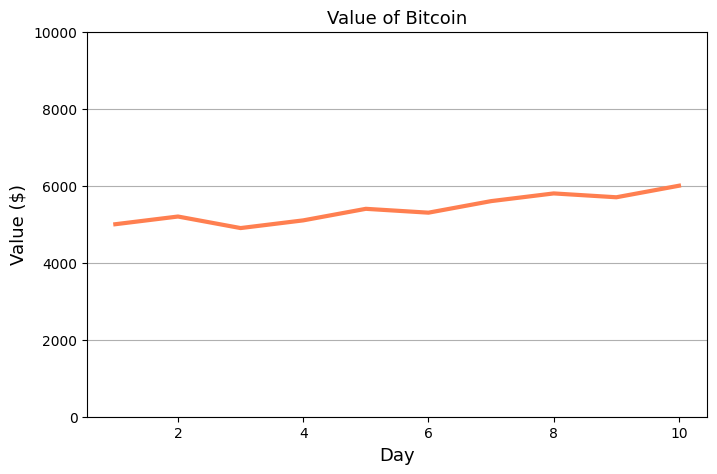

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

# Sample data
days = list(range(1, 11))
btc  = [5000, 5200, 4900, 5100, 5400, 5300, 5600, 5800, 5700, 6000]
rbtc = [3000, 3100, 2900, 3200, 3400, 3300, 3500, 3600, 3700, 3800]
etr  = [2000, 2100, 1900, 2200, 2300, 2200, 2400, 2500, 2600, 2700]

# --- Single line chart ---
plt.figure(figsize=(8, 5))
plt.plot(days, btc, color="coral", linewidth=3)
plt.title('Value of Bitcoin', fontsize=13)
plt.ylim(0, 10000)
plt.grid(axis="y")
plt.xlabel('Day', fontsize=13)
plt.ylabel('Value ($)', fontsize=13)
plt.show()

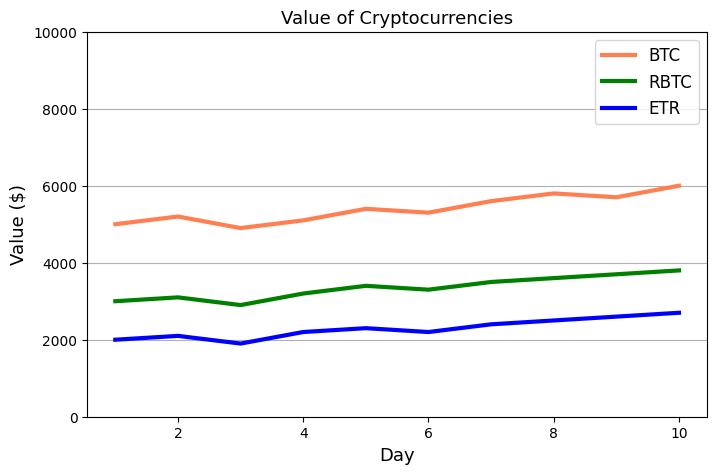

In [29]:
# --- Multiple lines on same graph ---
plt.figure(figsize=(8, 5))
plt.plot(days, btc,  color="coral", linewidth=3)
plt.plot(days, rbtc, color="green", linewidth=3)
plt.plot(days, etr,  color="blue",  linewidth=3)
plt.title('Value of Cryptocurrencies', fontsize=13)
plt.ylim(0, 10000)
plt.grid(axis="y")
plt.xlabel('Day', fontsize=13)
plt.ylabel('Value ($)', fontsize=13)
plt.legend(["BTC", "RBTC", "ETR"], fontsize=12)
plt.show()

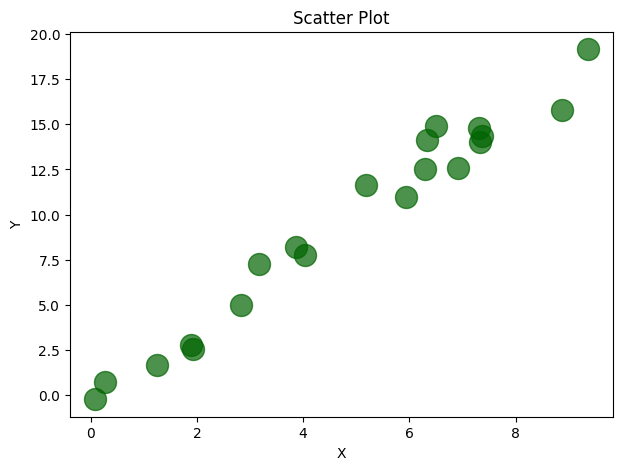

In [30]:
# --- Scatter plot ---
import numpy as np
x = np.random.rand(20) * 10
y = x * 2 + np.random.randn(20)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=250, alpha=0.7, color="darkgreen")
plt.title("Scatter Plot")
plt.xlabel("X"); plt.ylabel("Y")
plt.show()

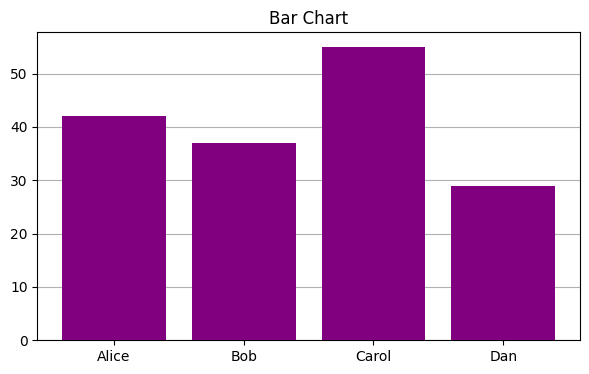

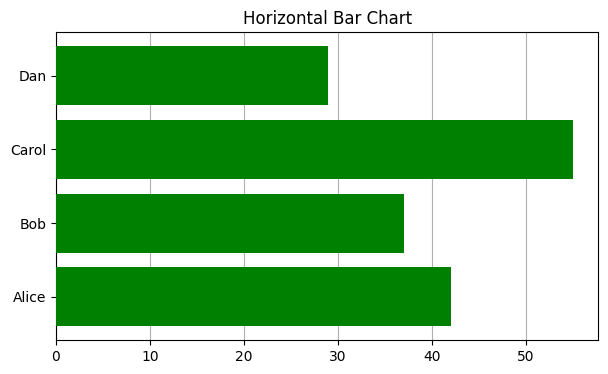

In [31]:
# --- Bar chart ---
names  = ["Alice", "Bob", "Carol", "Dan"]
values = [42, 37, 55, 29]

plt.figure(figsize=(7, 4))
plt.bar(names, values, color="purple", zorder=3)  # zorder=3 keeps bars above grid
plt.grid(axis="y", zorder=0)
plt.title("Bar Chart")
plt.show()

# --- Horizontal bar chart ---
y_pos = range(len(names))
plt.figure(figsize=(7, 4))
plt.barh(y_pos, values, align='center', color="green", zorder=3)
plt.yticks(y_pos, names)
plt.grid(axis="x", zorder=0)
plt.title("Horizontal Bar Chart")
plt.show()

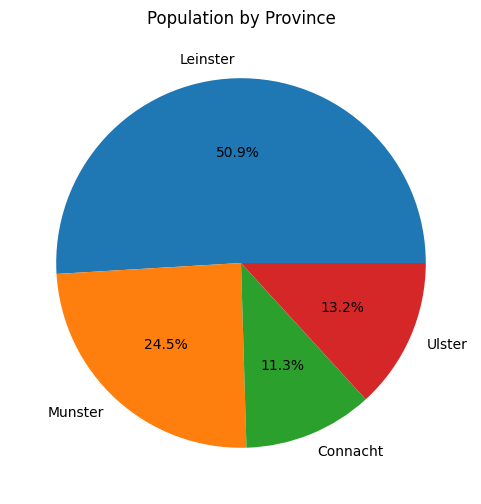

In [32]:
# --- Pie chart ---
provinces   = ["Leinster", "Munster", "Connacht", "Ulster"]
populations = [2.7, 1.3, 0.6, 0.7]

plt.figure(figsize=(6, 6))
plt.pie(populations, labels=provinces, autopct='%1.1f%%')
plt.title("Population by Province")
plt.savefig("sample-pie-chart.png")  # save to file
plt.show()

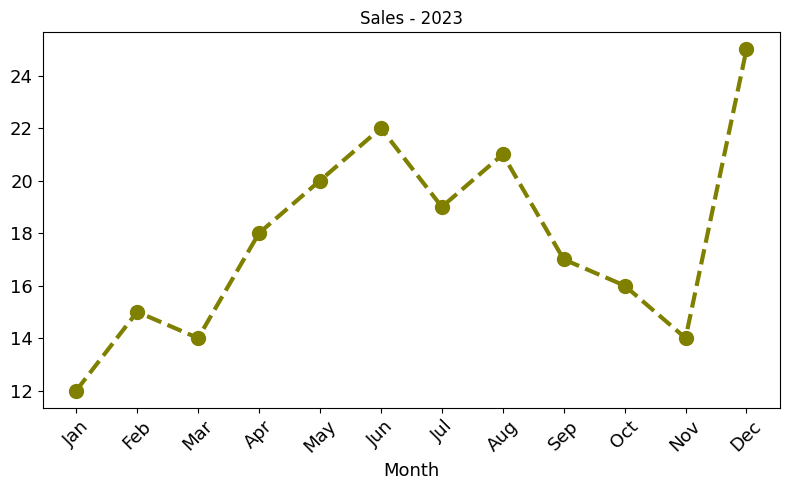

In [33]:
# --- DataFrame .plot() with customisation ---
import calendar
months = list(calendar.month_abbr)[1:]  # Jan–Dec
sales_2023 = pd.Series([12,15,14,18,20,22,19,21,17,16,14,25], index=months)

plot_axis = sales_2023.plot(
    title="Sales - 2023",
    figsize=(8, 5),
    fontsize=13,
    marker="o",
    markersize=10,
    color="olive",
    linewidth=3,
    linestyle="dashed"
)
plot_axis.set_xticks(range(len(sales_2023)))
plot_axis.set_xticklabels(sales_2023.index, rotation=45)
plot_axis.set_xlabel("Month", fontsize=13)
plt.tight_layout()
plt.show()

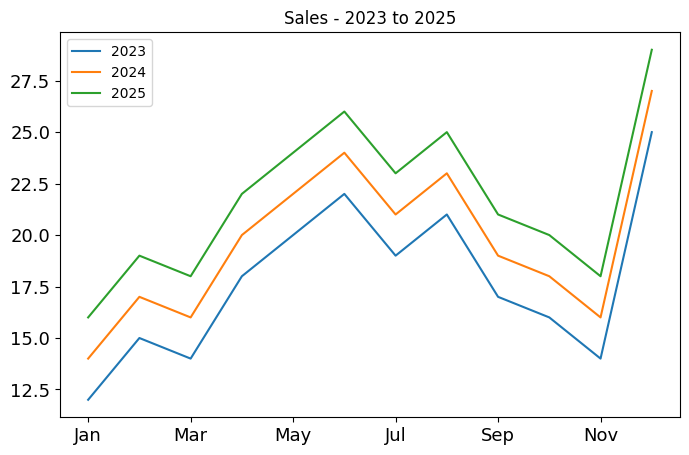

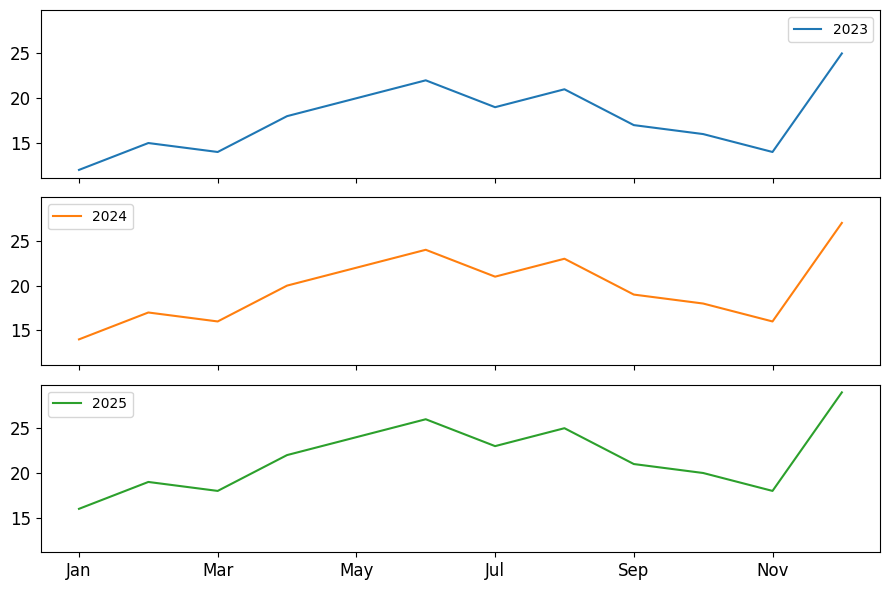

In [34]:
# --- Multiple line plot from DataFrame + subplots ---
salesdata = pd.DataFrame({
    "2023": [12,15,14,18,20,22,19,21,17,16,14,25],
    "2024": [14,17,16,20,22,24,21,23,19,18,16,27],
    "2025": [16,19,18,22,24,26,23,25,21,20,18,29]
}, index=months)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# All on one graph
salesdata.plot(title="Sales - 2023 to 2025", figsize=(8, 5), fontsize=13, color=colors)
plt.show()

# Each year as its own subplot (sharey = shared y-axis scale)
salesdata.plot(subplots=True, figsize=(9, 6), sharey=True, fontsize=12)
plt.tight_layout()
plt.show()

---
## 13. Machine Learning — Linear Regression

- `model.fit(X, y)` — learn slope and intercept
- `model.predict(X_new)` — make predictions
- `model.intercept_[0]`, `model.coef_[0][0]` — intercept and slope
- `df.corr()` — correlation matrix
- `mean_squared_error(y_test, y_pred)` — MSE evaluation
- Reshape: `df[["col"]].values` gives 2D array needed by sklearn

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Reproducible results
random.seed(100)
np.random.seed(100)

# Format floats nicely
pd.options.display.float_format = '{:,.2f}'.format

# Create synthetic data
n = 50
x_vals = np.linspace(0, 100, n)
y_vals = 2.5 * x_vals + 10 + np.random.randn(n) * 15
df_synthetic = pd.DataFrame({"x": x_vals, "y": y_vals})

# Reshape for sklearn: must be 2D
x = df_synthetic[["x"]].values
y = df_synthetic[["y"]].values

# Fit the model
model = LinearRegression()
model.fit(x, y)

print(f"Model intercept is {model.intercept_[0]:.2f}")
print(f"Model slope is {model.coef_[0][0]:.2f}")
print(f"Learned equation: y = {model.coef_[0][0]:.2f}x + {model.intercept_[0]:.2f}")

# Predict unseen values
x_unseen = np.array([[25], [50], [75]])
print("Predictions:", model.predict(x_unseen).flatten())

Model intercept is 13.43
Model slope is 2.42
Learned equation: y = 2.42x + 13.43
Predictions: [ 73.90813925 134.38798938 194.86783952]


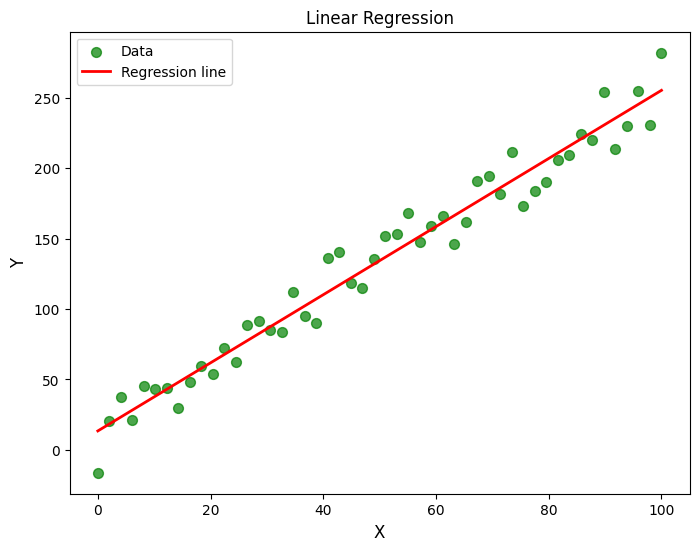

In [36]:
# Scatter plot with regression line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=50, color="green", alpha=0.7, label="Data")
plt.plot(x, model.predict(x), linewidth=2, color="red", label="Regression line")
plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.title("Linear Regression")
plt.legend()
plt.show()

MSE = 270.56
   Actual  Predicted  SquaredError
0   88.58      76.73        140.46
1  190.49     209.01        342.79
2  166.40     163.22         10.10
3  213.60     239.53        672.80
4  112.18      97.08        228.08


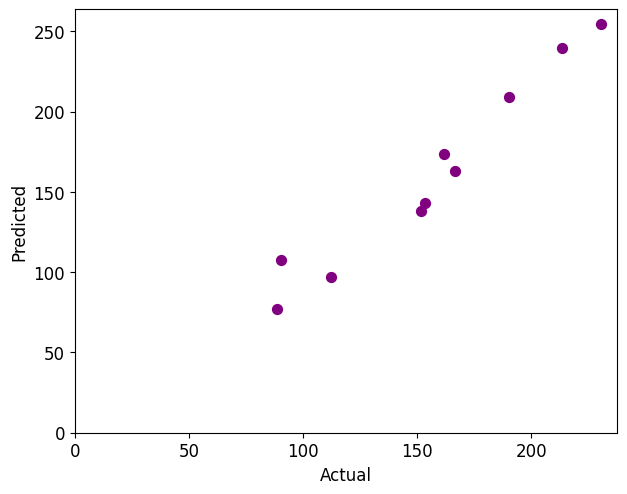

In [37]:
# Train/test split and MSE evaluation
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"MSE = {mse:.2f}")

# Compare actual vs predicted
df_comparison = pd.DataFrame({
    "Actual":    y_test.ravel(),
    "Predicted": y_pred.ravel()
})
df_comparison["SquaredError"] = (df_comparison["Actual"] - df_comparison["Predicted"]) ** 2
print(df_comparison.head())

# Scatter: actual vs predicted
ax = df_comparison.plot("Actual", "Predicted", kind="scatter", s=50,
                        fontsize=12, figsize=(7, 5.5), color="purple", xlim=0, ylim=0)
plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.show()

In [38]:
# Multiple linear regression — coefficient table
X_multi = pd.DataFrame({
    "R&D":         [165349, 162598, 153442, 144372, 142107],
    "Marketing":   [471784, 443899, 407934, 383199, 366168],
    "Administration": [136898, 151378, 128455, 108734, 91392]
})
y_profit = np.array([192261, 191792, 191050, 182902, 166188])

model_multi = LinearRegression()
model_multi.fit(X_multi, y_profit)

coef_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=["Coefficients"])
print(coef_df)

                Coefficients
R&D                    -2.82
Marketing               0.52
Administration          0.75


---
## 14. Machine Learning — Classification & Evaluation

### Evaluation metrics
- `accuracy_score` — fraction correct
- `precision_score` — of predicted positives, how many are correct
- `recall_score` — of actual positives, how many were found
- `f1_score` — harmonic mean of precision and recall
- `confusion_matrix` + `ConfusionMatrixDisplay` — visual confusion matrix
- `classification_report` — full summary table

### Cross-validation
- `cross_val_score(model, X, y, cv=5, scoring="accuracy")` — 5-fold CV
- `acc_scores.mean()` — mean accuracy across folds

### Scaling
- `MinMaxScaler` — scales to [0, 1]
- `StandardScaler` — zero mean, unit variance
- Always fit on training data, then `transform` unseen data (do NOT re-fit)

In [39]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load sample dataset
iris = load_iris()
data   = pd.DataFrame(iris.data,   columns=iris.feature_names)
target = pd.Series(iris.target_names[iris.target])

# Scale features
normalizer   = MinMaxScaler()               # or StandardScaler()
data_scaled  = normalizer.fit_transform(data.values)

# Train/test split
data_train, data_test, target_train, target_test = train_test_split(
    data_scaled, target, test_size=0.2, random_state=42
)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(data_train, target_train)
predicted = knn.predict(data_test)

print("Accuracy:", accuracy_score(target_test, predicted))

Accuracy: 1.0


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


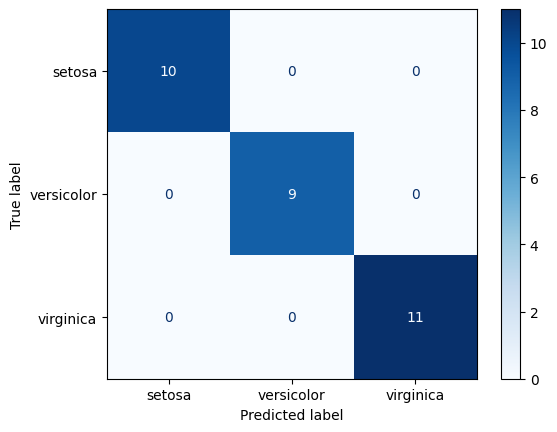

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [40]:
# Confusion matrix
cm = confusion_matrix(target_test, predicted)
print(cm)

labels = knn.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.show()

# Full classification report
print(classification_report(target_test, predicted, target_names=labels))

In [41]:
# 5-fold cross-validation — KNN, Logistic Regression, SVM
from sklearn import linear_model
from sklearn.svm import SVC

knn = KNeighborsClassifier(n_neighbors=3)
acc_scores = cross_val_score(knn, data_scaled, target, cv=5, scoring="accuracy")
for i, score in enumerate(acc_scores, start=1):
    print(f"Fold {i} accuracy: {score:.3f}")
print(f"KNN (k=3): Mean = {acc_scores.mean():.3f}")

lr = linear_model.LogisticRegression(solver="lbfgs", max_iter=200)
acc_scores = cross_val_score(lr, data_scaled, target, cv=5, scoring="accuracy")
print(f"Logistic Regression: Mean = {acc_scores.mean():.3f}")

svm = SVC(gamma="auto")
acc_scores = cross_val_score(svm, data_scaled, target, cv=5, scoring="accuracy")
print(f"SVM: Mean = {acc_scores.mean():.3f}")

Fold 1 accuracy: 0.967
Fold 2 accuracy: 0.967
Fold 3 accuracy: 0.933
Fold 4 accuracy: 0.900
Fold 5 accuracy: 1.000
KNN (k=3): Mean = 0.953
Logistic Regression: Mean = 0.927
SVM: Mean = 0.960


In [42]:
# Tune k — find best number of neighbours
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    acc_scores = cross_val_score(knn, data_scaled, target, cv=5, scoring="accuracy")
    mean_acc = acc_scores.mean()
    print(f"K={k:02d} neighbours: Accuracy={mean_acc:.3f}")

K=01 neighbours: Accuracy=0.953
K=02 neighbours: Accuracy=0.960
K=03 neighbours: Accuracy=0.953
K=04 neighbours: Accuracy=0.967
K=05 neighbours: Accuracy=0.960
K=06 neighbours: Accuracy=0.967
K=07 neighbours: Accuracy=0.960
K=08 neighbours: Accuracy=0.960
K=09 neighbours: Accuracy=0.960
K=10 neighbours: Accuracy=0.960


In [43]:
# Tune max_depth for Decision Tree
from sklearn.tree import DecisionTreeClassifier

for depth in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=1)
    dt_model = dt.fit(data_train, target_train)
    dt_predicted = dt_model.predict(data_test)
    dt_acc = accuracy_score(target_test, dt_predicted)
    print(f"max_depth={depth:02d}: Accuracy={dt_acc:.3f}")

max_depth=01: Accuracy=0.633
max_depth=02: Accuracy=0.967
max_depth=03: Accuracy=1.000
max_depth=04: Accuracy=1.000
max_depth=05: Accuracy=1.000
max_depth=06: Accuracy=1.000
max_depth=07: Accuracy=1.000
max_depth=08: Accuracy=1.000
max_depth=09: Accuracy=1.000
max_depth=10: Accuracy=1.000


In [44]:
# Normalisation — fit on train, transform test (NEVER re-fit on test)
normalizer = MinMaxScaler()
data_scaled   = normalizer.fit_transform(data.values)  # fit + transform train

unseen_data   = np.array([[5.1, 3.5, 1.4, 0.2]])       # example unseen sample
unseen_scaled = normalizer.transform(unseen_data)       # transform only (no fit!)
print("Unseen data scaled:", unseen_scaled)

Unseen data scaled: [[0.22222222 0.625      0.06779661 0.04166667]]


---
## 15. Text Processing & NLP

- `re.sub(r"[^a-zA-Z0-9\s]", "", text)` — remove special characters
- `re.sub(r"[^a-z\s]", "", text)` — keep only lowercase letters and spaces
- `TfidfVectorizer(max_features=5000, stop_words='english')` — convert text to TF-IDF matrix
- `tfidf.fit_transform(train)` — fit on train
- `tfidf.transform(test)` — apply to test (no refit)
- `reviews_df["col"].apply(func)` — apply function to every row

In [45]:
import re
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Strip HTML tags using BeautifulSoup
def html_to_text(html):
    if not isinstance(html, str):
        return ""
    return BeautifulSoup(html, "html.parser").get_text(separator=" ")

# Remove special characters from a string
def remove_special_chars(text):
    if isinstance(text, str):
        return re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

# Full text cleaning: lowercase + keep only letters/spaces
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

# Demo
sample_reviews = pd.DataFrame({
    "review_body":  ["<p>This product is <b>GREAT</b>!</p>",
                     "Terrible... waste of money!!!",
                     "<div>Okay product, nothing special.</div>"],
    "review_title": ["Love it!", "Waste of money!!!", "Just OK."],
    "Sentiment":    [1, 0, 1]
})

# Apply transformations
sample_reviews["review_body"]  = sample_reviews["review_body"].apply(html_to_text)
sample_reviews["review_title"] = sample_reviews["review_title"].apply(remove_special_chars)
sample_reviews["review_body"]  = sample_reviews["review_body"].apply(clean_text)

print(sample_reviews)

                    review_body    review_title  Sentiment
0       this product is  great          Love it          1
1       terrible waste of money  Waste of money          0
2  okay product nothing special         Just OK          1


In [46]:
# Larger sample for TF-IDF demo
texts = [
    "this product is absolutely amazing love it",
    "terrible product waste of money do not buy",
    "great quality highly recommend to everyone",
    "bad experience broken on arrival very disappointed",
    "excellent fast delivery good packaging overall satisfied",
    "worst purchase ever complete garbage return immediately",
    "really good value for money would buy again",
    "poor quality item not as described avoid at all costs",
]
labels = [1, 0, 1, 0, 1, 0, 1, 0]  # 1=positive, 0=negative

df_reviews = pd.DataFrame({"review_body": texts, "Sentiment": labels})
train_df, test_df = train_test_split(df_reviews, test_size=0.25, random_state=42)

# Fit TF-IDF on training data only
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(train_df["review_body"])
y_train = train_df["Sentiment"]

X_test = tfidf.transform(test_df["review_body"])  # transform only!
y_test = test_df["Sentiment"]

# Train and evaluate classifiers
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))

log_model = LogisticRegression(solver="lbfgs", max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

evaluate(y_test, y_pred_log,  "Logistic Regression")
evaluate(y_test, y_pred_tree, "Decision Tree")


Logistic Regression
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Decision Tree
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


---
## 16. Feature Selection & Importance

- **Forward selection** — starts with no features, adds the best one each step
- **Backward selection** — starts with all features, removes the worst one each step
- `SequentialFeatureSelector(model, n_features_to_select=3, direction="forward")`
- `sfs.get_support()` — boolean mask of selected features
- **Permutation importance** — how much accuracy drops when each feature is shuffled

In [47]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
data   = pd.DataFrame(iris.data, columns=iris.feature_names)
target = iris.target

knn = KNeighborsClassifier(n_neighbors=3)

# --- Forward Selection ---
sfs_forward = SequentialFeatureSelector(
    knn, n_features_to_select=3, direction="forward"
).fit(data, target)

feature_mask_fwd  = sfs_forward.get_support()
features_forward  = list(data.iloc[:, feature_mask_fwd].columns)
print("Forward selected features:", features_forward)

# --- Backward Selection ---
sfs_backward = SequentialFeatureSelector(
    knn, n_features_to_select=3, direction="backward"
).fit(data, target)

feature_mask_bwd  = sfs_backward.get_support()
features_backward = list(data.iloc[:, feature_mask_bwd].columns)
print("Backward selected features:", features_backward)

Forward selected features: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']
Backward selected features: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']


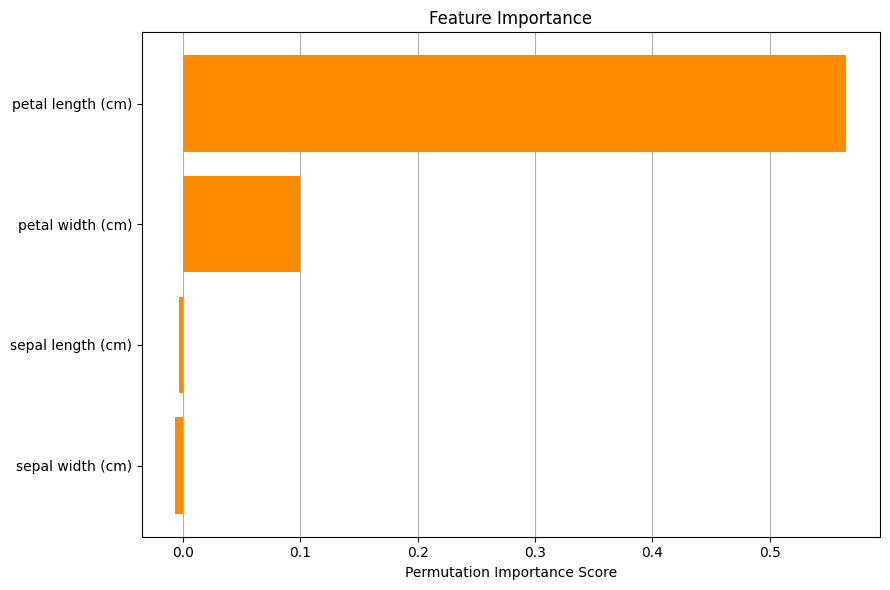

In [48]:
# --- Permutation Importance ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(data, target)

result      = permutation_importance(knn, data, target, n_repeats=10, random_state=0)
importances = result.importances_mean
sorted_idx  = importances.argsort()

plt.figure(figsize=(9, 6))
plt.barh(data.columns[sorted_idx], importances[sorted_idx], color="darkorange", zorder=3)
plt.xlabel("Permutation Importance Score")
plt.title("Feature Importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()